In [1]:
using Pkg
Pkg.activate(".")
Pkg.add(["ITensors","ITensorMPS","Compat","OrdinaryDiffEqTsit5",
        "Graphs","NamedGraphs","SpecialFunctions",
        "Observers","KrylovKit","Plots","DataFrames","HDF5"])
Pkg.instantiate()

  Activating project at `~/Documents/MacbookPro/TDVP Expansion`
    Updating registry at `~/.julia/registries/General.toml`
     Project No packages added to or removed from `~/Documents/MacbookPro/TDVP Expansion/Project.toml`
    Manifest No packages added to or removed from `~/Documents/MacbookPro/TDVP Expansion/Manifest.toml`


In [2]:
include("1DExpansion.jl")

function densityheatmap(filename;opts...)
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    heatmap(times,sites,densities;xlabel="t",ylabel="x",opts...)
end 

densityheatmap (generic function with 1 method)

In [6]:
midfiles=readdir("mid")

830-element Vector{String}:
 "mosU0.out"
 "mosU0w0.hdf5"
 "mosU0w10.hdf5"
 "mosU0w100.hdf5"
 "mosU0w110.hdf5"
 "mosU0w120.hdf5"
 "mosU0w130.hdf5"
 "mosU0w140.hdf5"
 "mosU0w150.hdf5"
 "mosU0w160.hdf5"
 "mosU0w170.hdf5"
 "mosU0w180.hdf5"
 "mosU0w190.hdf5"
 ⋮
 "mosU9w420.hdf5"
 "mosU9w430.hdf5"
 "mosU9w440.hdf5"
 "mosU9w450.hdf5"
 "mosU9w460.hdf5"
 "mosU9w470.hdf5"
 "mosU9w480.hdf5"
 "mosU9w50.hdf5"
 "mosU9w60.hdf5"
 "mosU9w70.hdf5"
 "mosU9w80.hdf5"
 "mosU9w90.hdf5"

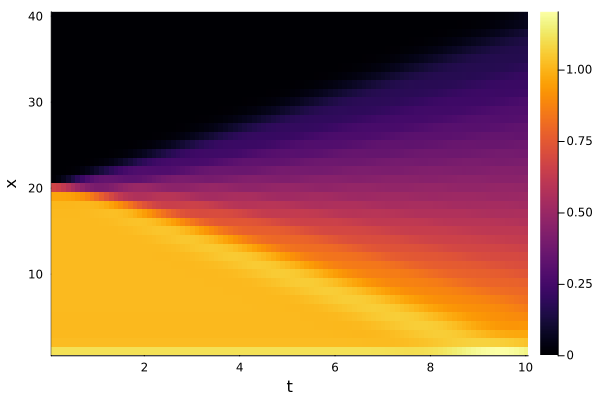

In [24]:
densityheatmap("mid/mosU20w0.hdf5")

In [26]:
function wts(filename)
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    widths=[fwd(d) for d in eachcol(densities)]
    return (;times,sites,densities,widths)
end

wts (generic function with 1 method)

In [93]:
ho=h5open("mid/mosU0w0.hdf5")

🗂️ HDF5.File: (read-only) mid/mosU0w0.hdf5
├─ 🔢 densities
├─ 🔢 probs
├─ 🔢 sites
└─ 🔢 times

In [95]:
hd=h5read("mid/mosU0w0.hdf5","probs");
size(hd)

(40, 21, 100)

In [107]:
nd(hd[:,:,1])

3.242340772018005

In [108]:
doublons(hd[:,:,1])

40-element Vector{Float64}:
 0.2850253265203081
 0.2847578100813351
 0.28398157740634816
 0.2822200106522457
 0.2787739656900489
 0.2727635866544762
 0.2632207259110007
 0.24923654552343222
 0.23015248996304338
 0.2057946700708525
 0.17669301265888265
 0.1442104204481112
 0.1105015319477053
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [103]:
h5read("mid/mosU0w0.hdf5","times")

100-element Vector{Float64}:
 0.1
 0.2
 0.30000000000000004
 0.4
 0.5
 0.6
 0.7
 0.7999999999999999
 0.8999999999999999
 0.9999999999999999
 1.0999999999999999
 1.2
 1.3
 ⋮
 8.899999999999984
 8.999999999999984
 9.099999999999984
 9.199999999999983
 9.299999999999983
 9.399999999999983
 9.499999999999982
 9.599999999999982
 9.699999999999982
 9.799999999999981
 9.89999999999998
 9.99999999999998

In [45]:
function sval(st,startchar,endchar;tp=Int)
    sv=findfirst(startchar,st)[end]+1
    ev=findfirst(endchar,st)[1]-1
    parse(tp,st[sv:ev])
end

sval (generic function with 1 method)

In [46]:
sval("mosU20w0.hdf5","U","w")

20

In [47]:
sval("mosU20w0.hdf5","w",".")

0

In [49]:
midfiles

830-element Vector{String}:
 "mosU0.out"
 "mosU0w0.hdf5"
 "mosU0w10.hdf5"
 "mosU0w100.hdf5"
 "mosU0w110.hdf5"
 "mosU0w120.hdf5"
 "mosU0w130.hdf5"
 "mosU0w140.hdf5"
 "mosU0w150.hdf5"
 "mosU0w160.hdf5"
 "mosU0w170.hdf5"
 "mosU0w180.hdf5"
 "mosU0w190.hdf5"
 ⋮
 "mosU9w420.hdf5"
 "mosU9w430.hdf5"
 "mosU9w440.hdf5"
 "mosU9w450.hdf5"
 "mosU9w460.hdf5"
 "mosU9w470.hdf5"
 "mosU9w480.hdf5"
 "mosU9w50.hdf5"
 "mosU9w60.hdf5"
 "mosU9w70.hdf5"
 "mosU9w80.hdf5"
 "mosU9w90.hdf5"

In [59]:
"""
    linearfit(X,Y,functions)

takes a set of `X=(x1,x2,...xn)`, `Y=(y1,y1,...yn)` and a set of `functions=(f1, f2,...fm)` 
and returns the set of coefficients `C=(c1,c2,..cm)` which minimize 


         n       m
    χ²=  ∑  (yi- ∑  cj fj(xi))^2
        i=1     j=1

It is implemented by constructing the `n×m` matrix `A` with matrix elements

    Aᵢⱼ= fj(xi)

then `(AᵗA)C=AᵗY`, where `Y=(y1,y2,...yn)`.  Thus the optimal coefficients are 
`(AᵗA)⁻¹(AᵗY)`, which can be implemented with `(AᵗA)\\(AᵗY)`.
"""
function linearfit(X,Y,functions)
    A=[f(x) for x in X, f in functions ]
    return transpose(A)*A\(transpose(A)*Y) # This is equivalent to (AᵗA)⁻¹(AᵗY)
end                                        # the "\" is "divide from left"

linearfit

In [60]:
function longslope(xvals,yvals;startindex=1,endindex=length(xvals))
    xv=@view xvals[startindex:endindex]
    yv=@view yvals[startindex:endindex]
    lf=linearfit(xv,yv,[x->1.,x->x*1.])
    lf[2]
end

longslope (generic function with 1 method)

In [64]:
function showwidths(targU)
    p=plot(;title="$targU",xlabel="t",label="width",legend_columns=3)
    for file in midfiles
        if !endswith(file,"hdf5")
            continue
        end
        U=0.1*sval(file,"U","w")
        w=0.01*sval(file,"w",".")
        if U != targU
            continue
        end
        data=wts("mid/"*file)
        speed=longslope(data.times,data.widths;startindex=10)
        plot!(data.times,data.widths;label="$(round(w;digits=1))")
    end
    p
end

showwidths (generic function with 1 method)

In [161]:
function speeds(targU;startindex=10)
    wvals=[]
    speedvals=[]
    for file in midfiles
        if !endswith(file,"hdf5")
            continue
        end
        U=0.1*sval(file,"U","w")
        w=0.01*sval(file,"w",".")
        if U != targU
            continue
        end
        data=wts("mid/"*file)
        speed=longslope(data.times,data.widths;startindex)
        push!(wvals,w)
        push!(speedvals,speed)
    end
    p=sortperm(wvals)
    return ([wvals[p]...],[speedvals[p]...])
end

speeds (generic function with 1 method)

In [74]:
Uvals=vcat(0:0.1:0.9,1:10);

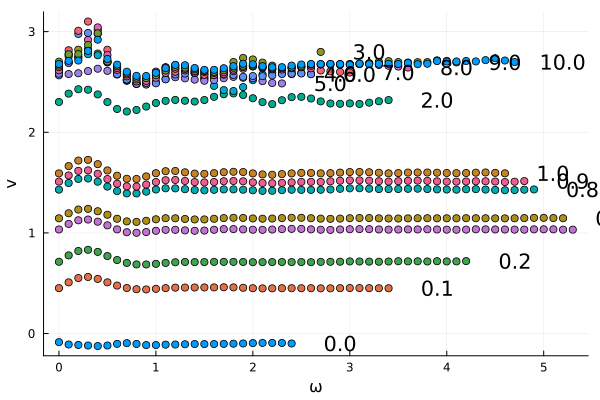

In [166]:
p=plot(;xlabel="ω",ylabel="v")
for U in Uvals
    sp=speeds(U;startindex=16)
    if length(sp[1])>0
        scatter!(sp...;label="")
        x=sp[1][end]
        y=sp[2][end]
        annotate!((x+0.5,y,"$(round(U;digits=1))"))
    end
end
p

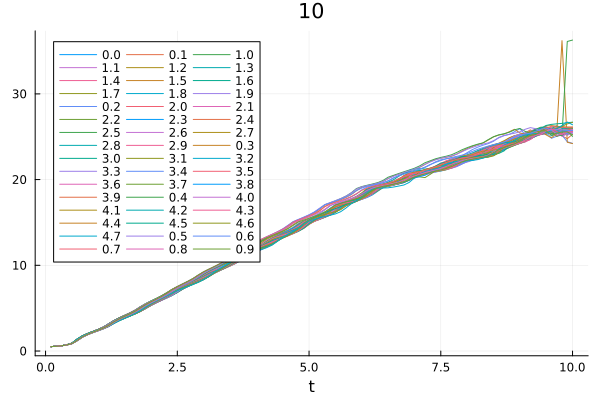

In [171]:
showwidths(10)

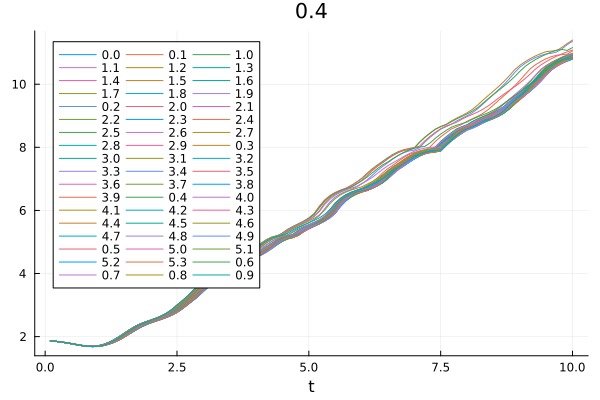

In [65]:
showwidths(0.4)

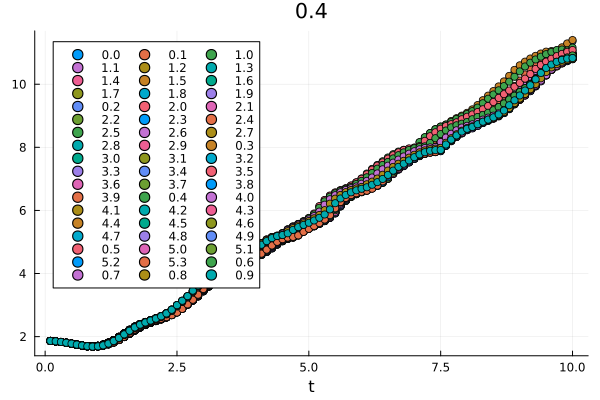

In [61]:
targU=0.4
p=plot(;title="$targU",xlabel="t",label="width",legend_columns=3)
for file in midfiles
    if !endswith(file,"hdf5")
        continue
    end
    U=0.1*sval(file,"U","w")
    w=0.01*sval(file,"w",".")
    if U != targU
        continue
    end
    data=wts("mid/"*file)
    speed=longslope(data.times,data.widths;startindex=10)
    scatter!(data.times,data.widths;label="$(round(w;digits=1))")
end
p

In [90]:
doublons(probs)=[row[3] for row in eachrow(probs)]

doublons (generic function with 1 method)

In [91]:
nd(probs)=sum(doublons(probs))

nd (generic function with 1 method)

In [113]:
function doublontimeseries(targU)
    wvals=[]
    dvs=[]
    ts=[]
    for file in midfiles
        if !endswith(file,"hdf5")
            continue
        end
        U=0.1*sval(file,"U","w")
        w=0.01*sval(file,"w",".")
        if U != targU
            continue
        end
        filename=file
        times=h5read("mid/"*filename,"times")
        sites=h5read("mid/"*filename,"sites")
        densities=h5read("mid/"*filename,"densities")
        probs=h5read("mid/"*filename,"probs")
        nt=length(times)
        doublonseries=Vector{Float64}(undef,nt)
        for j in 1:nt
            doublonseries[j]=nd(probs[:,:,j])
        end
        push!(wvals,w)
        push!(dvs,doublonseries)
        push!(ts,times)
    end
    p=sortperm(wvals)
    return (w=[wvals[p]...],doublonseries=[dvs[p]...],times=[ts[p]...])
end

doublontimeseries (generic function with 1 method)

In [115]:
dt2=doublontimeseries(2);

In [172]:
function showdtseries(data)
    p=plot(xlabel="t",ylabel="nd",legend_columns=4)
    ws=data.w
    for j in 1:length(ws)
        times=data.times[j]
        doublons=data.doublonseries[j]
        w=ws[j]
        plot!(times,doublons;label="$(round(w;digits=1))")
    end
    p
end

showdtseries (generic function with 1 method)

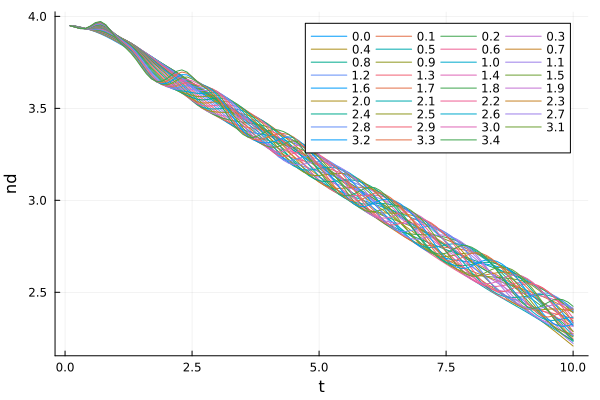

In [173]:
showdtseries(doublontimeseries(2))

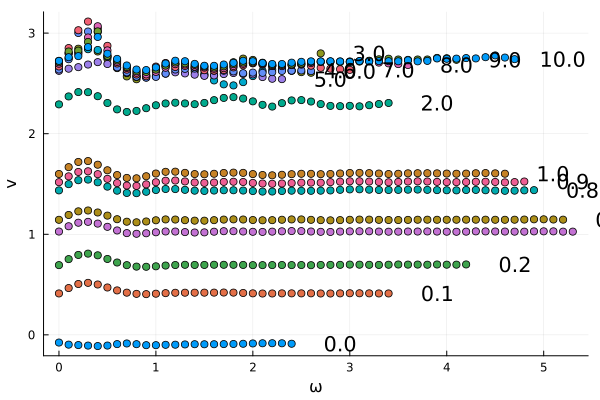

In [174]:
p=plot(;xlabel="ω",ylabel="v")
for U in Uvals
    sp=speeds(U)
    if length(sp[1])>0
        scatter!(sp...;label="")
        x=sp[1][end]
        y=sp[2][end]
        annotate!((x+0.5,y,"$(round(U;digits=1))"))
    end
end
p

# Old

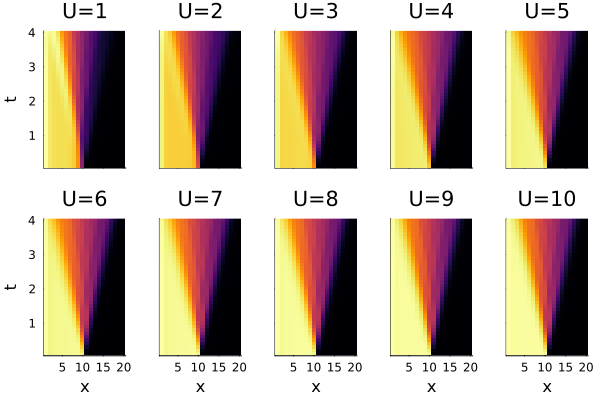

In [4]:
plots=[]
for U in 1:10
    filename="data/smallprod$U.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    p=heatmap(sites,times,densities';
        xlabel="x",ylabel="t", colorbar=:none,title="U=$U")
    push!(plots,p)
end
for U in 1:5
    plot!(plots[U],xformatter=_->"")
    xlabel!(plots[U],"")
end
for U in 2:5
    plot!(plots[U],yformatter=_->"")
    ylabel!(plots[U],"")
    plot!(plots[U+5],yformatter=_->"")
    ylabel!(plots[U+5],"")
end

plot(plots...,layout=(2,5), link = :both)
#plot([plots...],layout=collect(1:10))

In [5]:
plots=[]
for U in 1:10
    filename="data/bigprod$U.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    p=heatmap(sites,times,densities';
        xlabel="x",ylabel="t", colorbar=:none,title="U=$U")
    push!(plots,p)
end
for U in 1:5
    plot!(plots[U],xformatter=_->"")
    xlabel!(plots[U],"")
end
for U in 2:5
    plot!(plots[U],yformatter=_->"")
    ylabel!(plots[U],"")
    plot!(plots[U+5],yformatter=_->"")
    ylabel!(plots[U+5],"")
end

plot(plots...,layout=(2,5), link = :both,size=2 .*(800, 600))
#plot([plots...],layout=collect(1:10))
savefig("bigheat2.png")

"/Users/emueller/Documents/MacbookPro/TDVP Expansion/bigheat2.png"

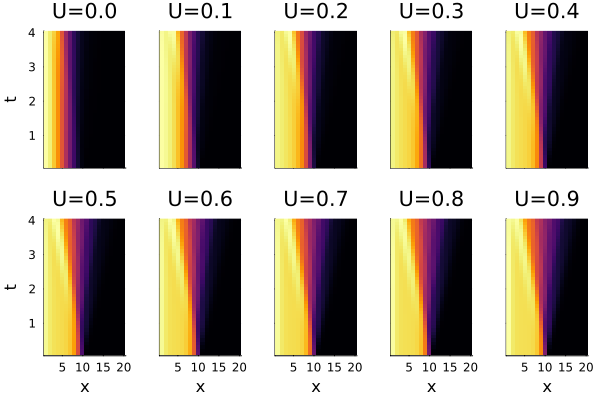

In [94]:
plots=[]
for dU in 0:9
    U=0.1*dU
    filename="data/smallprod0$dU.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    p=heatmap(sites,times,densities';
        xlabel="x",ylabel="t", colorbar=:none,title="U=$(round(U,digits=1))")
    push!(plots,p)
end
for U in 1:5
    plot!(plots[U],xformatter=_->"")
    xlabel!(plots[U],"")
end
for U in 2:5
    plot!(plots[U],yformatter=_->"")
    ylabel!(plots[U],"")
    plot!(plots[U+5],yformatter=_->"")
    ylabel!(plots[U+5],"")
end

plot(plots...,layout=(2,5), link = :both)
#plot([plots...],layout=collect(1:10))

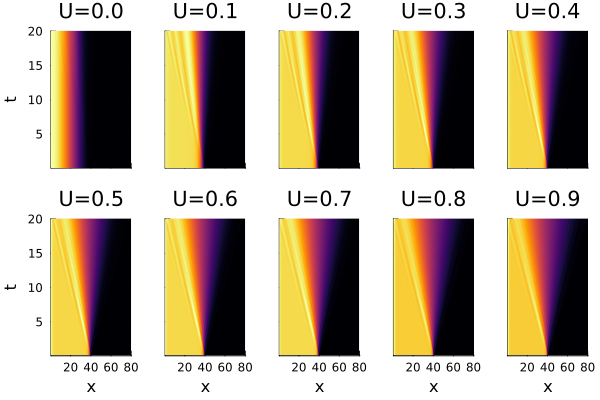

In [103]:
plots=[]
for dU in 0:9
    U=0.1*dU
    filename="data/bigprod0$dU.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    p=heatmap(sites,times,densities';
        xlabel="x",ylabel="t", colorbar=:none,title="U=$(round(U,digits=1))")
    push!(plots,p)
end
for U in 1:5
    plot!(plots[U],xformatter=_->"")
    xlabel!(plots[U],"")
end
for U in 2:5
    plot!(plots[U],yformatter=_->"")
    ylabel!(plots[U],"")
    plot!(plots[U+5],yformatter=_->"")
    ylabel!(plots[U+5],"")
end

p=plot(plots...,layout=(2,5), link = :both)
#plot([plots...],layout=collect(1:10))

In [107]:
plots=[]
for dU in 0:9
    U=0.1*dU
    filename="data/bigprod0$dU.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    p=heatmap(sites,times,densities';
        xlabel="x",ylabel="t", colorbar=:none,title="U=$(round(U,digits=1))")
    push!(plots,p)
end
for U in 1:5
    plot!(plots[U],xformatter=_->"")
    xlabel!(plots[U],"")
end
for U in 2:5
    plot!(plots[U],yformatter=_->"")
    ylabel!(plots[U],"")
    plot!(plots[U+5],yformatter=_->"")
    ylabel!(plots[U+5],"")
end

p=plot(plots...,layout=(2,5), link = :both,size=2 .*(800, 600))
#plot([plots...],layout=collect(1:10))
savefig("bigheat.png")

"/Users/emueller/Documents/Macbook Pro/TDVP Expansion/bigheat.png"

In [98]:
d01=h5read("data/bigprod02.hdf5","densities")
t01=h5read("data/bigprod02.hdf5","times")
s01=h5read("data/bigprod02.hdf5","sites");

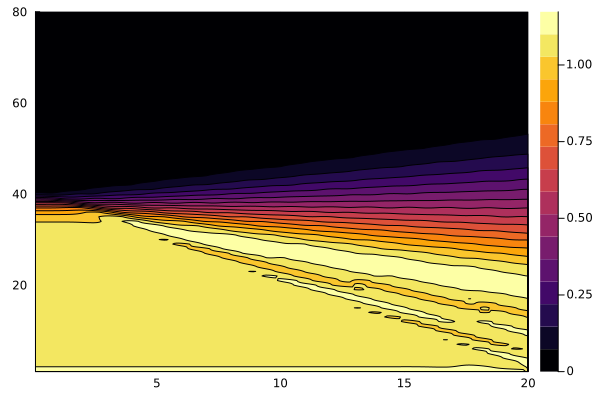

In [99]:
contourf(t01,s01,d01)

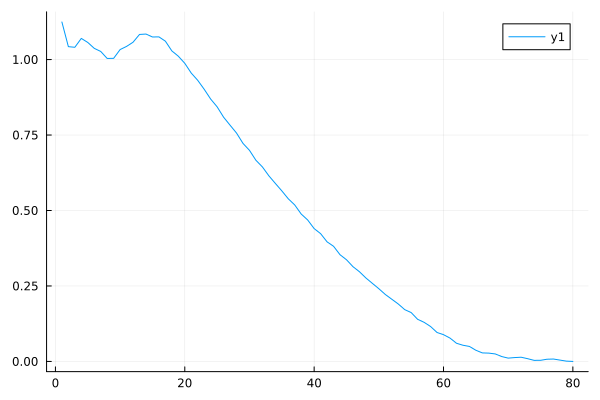

In [86]:
plot(s05,d05[:,end])

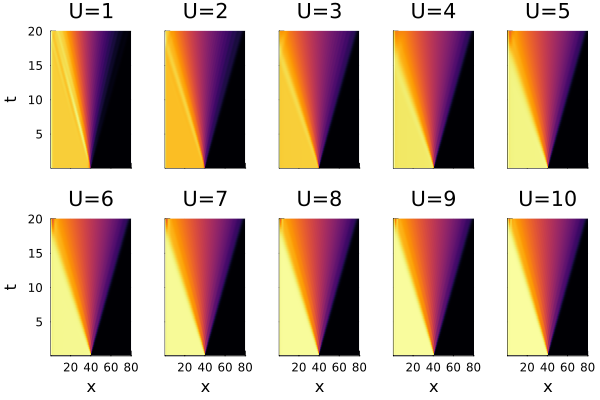

In [100]:
plots=[]
for U in 1:10
    # if U==4
    #     p=heatmap()
    #     push!(plots,p)
    #     continue
    # end
    filename="data/bigprod$U.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    p=heatmap(sites,times,densities';
        xlabel="x",ylabel="t", colorbar=:none,title="U=$U")
    push!(plots,p)
end
for U in 1:5
    plot!(plots[U],xformatter=_->"")
    xlabel!(plots[U],"")
end
for U in 2:5
    plot!(plots[U],yformatter=_->"")
    ylabel!(plots[U],"")
    plot!(plots[U+5],yformatter=_->"")
    ylabel!(plots[U+5],"")
end

plot(plots...,layout=(2,5), link = :both)
#plot([plots...],layout=collect(1:10))

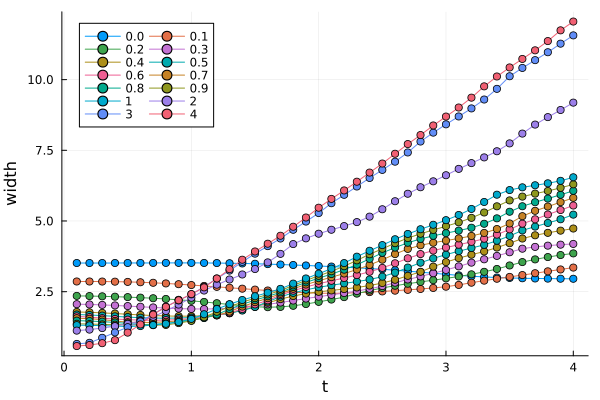

In [113]:
p=plot(;xlabel="t",ylabel="width",legend_columns = 2)
for dU in 0:9
    U=0.1*dU
    filename="data/smallprod0$dU.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    widths=[fwd(d) for d in eachcol(densities)]
    plot!(times,widths,label="$(round(U,digits=1))",
    marker =:circle)
end
for U in 1:4
    filename="data/smallprod$U.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    widths=[fwd(d) for d in eachcol(densities)]
    plot!(times,widths,label="$U",marker=:circle)
end
p
    

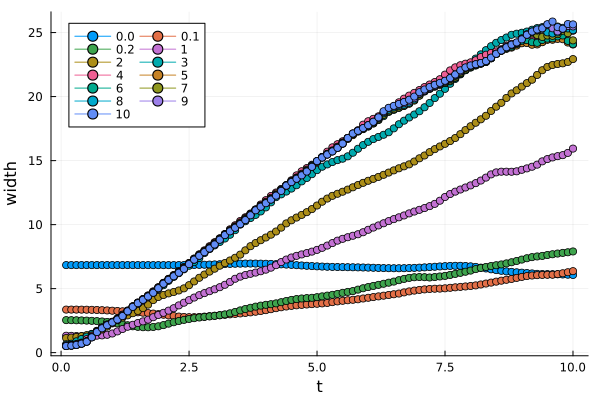

In [78]:
p=plot(;xlabel="t",ylabel="width",legend_columns = 2)
for dU in 0:2
    U=0.1*dU
    filename="medprod0$dU.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    widths=[fwd(d) for d in eachcol(densities)]
    plot!(times,widths,label="$(round(U,digits=1))",
    marker =:circle)
end
for U in 1:10
    filename="medprod$U.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    widths=[fwd(d) for d in eachcol(densities)]
    plot!(times,widths,label="$U",marker=:circle)
end
p

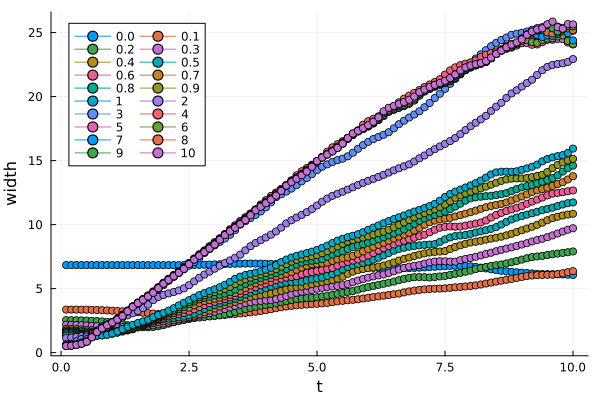

In [81]:
p=plot(;xlabel="t",ylabel="width",legend_columns = 2)
for dU in 0:9
    U=0.1*dU
    filename="medprod0$dU.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    widths=[fwd(d) for d in eachcol(densities)]
    plot!(times,widths,label="$(round(U,digits=1))",
    marker =:circle)
end
 for U in 1:10
     filename="medprod$U.hdf5"
     times=h5read(filename,"times")
     sites=h5read(filename,"sites")
     densities=h5read(filename,"densities")
     widths=[fwd(d) for d in eachcol(densities)]
     plot!(times,widths,label="$U",marker=:circle)
 end
p

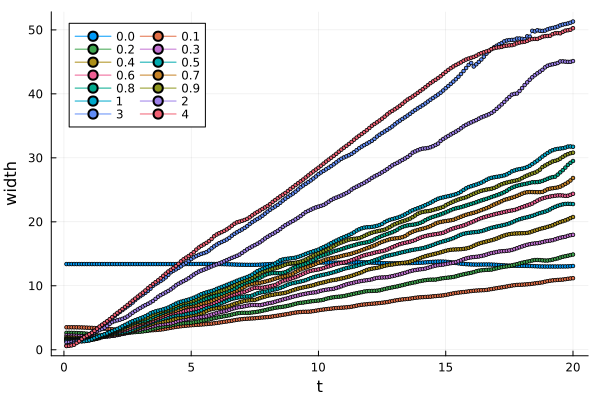

In [123]:
p=plot(;xlabel="t",ylabel="width",legend_columns = 2)
for dU in 0:9
    U=0.1*dU
    filename="data/bigprod0$dU.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    widths=[fwd(d) for d in eachcol(densities)]
    plot!(times,widths,label="$(round(U,digits=1))",
    marker =:circle,markersize=2)
end
 for U in 1:4
     filename="data/bigprod$U.hdf5"
     times=h5read(filename,"times")
     sites=h5read(filename,"sites")
     densities=h5read(filename,"densities")
     widths=[fwd(d) for d in eachcol(densities)]
     plot!(times,widths,label="$U",marker=:circle,markersize=2)
 end
p
savefig("widths.png")
p

In [46]:
d1=h5read("smallprod1.hdf5","densities");

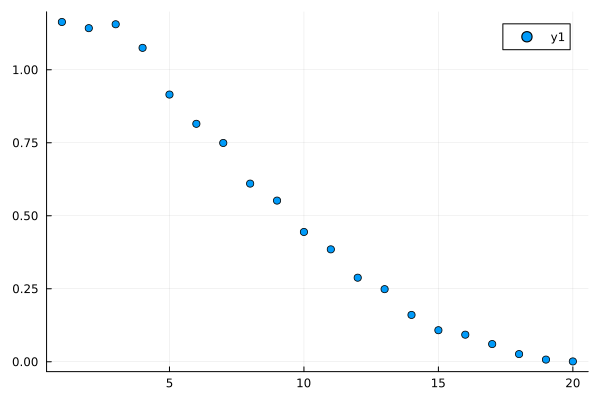

In [54]:
scatter(d1[:,end])

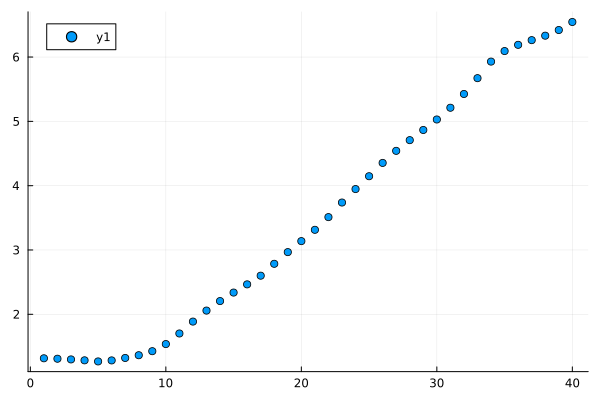

In [60]:
scatter([fwd(d) for d in eachcol(d1)])

In [50]:
fwd(d1[:,1])

1.315596164196343

In [58]:
for d in eachcol(d1)
    println(length(fwd(d)))
end

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [41]:
function fwd(d)
    m=maximum(d)
    a=linextrap(d,3*m/4)
    b=linextrap(d,m/4)
    return b-a
end   

fwd (generic function with 1 method)

In [20]:
tuple(collect(1:10)...)

(1, 2, 3, 4, 5, 6, 7, 8, 9, 10)

# Starting from product state

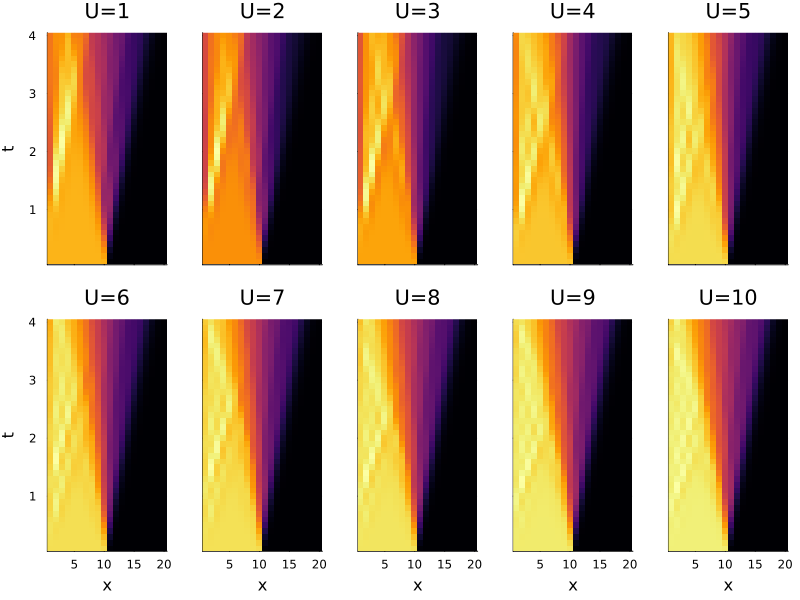

In [171]:
plots=[]
for U in 1:10
    # if U==4
    #     p=heatmap()
    #     push!(plots,p)
    #     continue
    # end
    filename="data/prodshort$U.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    p=heatmap(sites,times,densities';
        xlabel="x",ylabel="t", colorbar=:none,title="U=$U")
    push!(plots,p)
end
for U in 1:5
    plot!(plots[U],xformatter=_->"")
    xlabel!(plots[U],"")
end
for U in 2:5
    plot!(plots[U],yformatter=_->"")
    ylabel!(plots[U],"")
    plot!(plots[U+5],yformatter=_->"")
    ylabel!(plots[U+5],"")
end

p=plot(plots...,layout=(2,5), link = :both,size=(800, 600))
#plot([plots...],layout=collect(1:10))
savefig("prodshortheat.png")
p

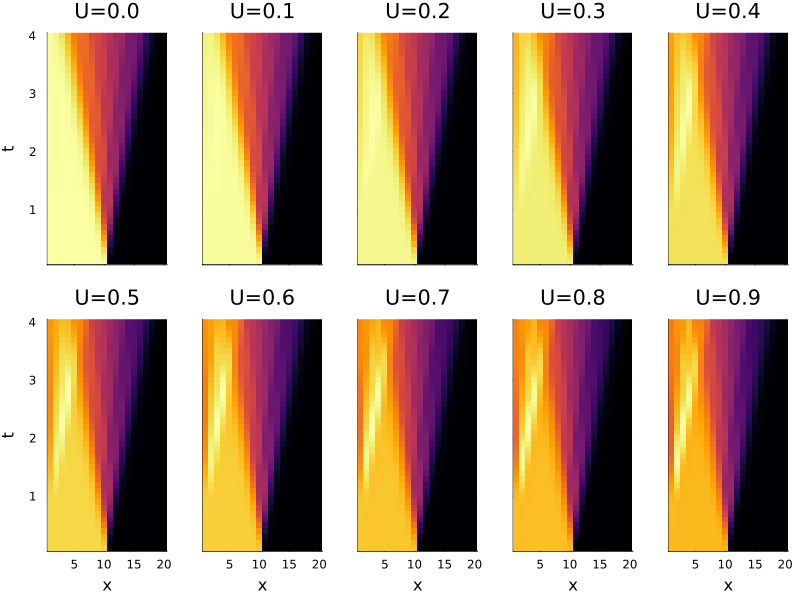

In [172]:
plots=[]
for wU in 0:9
    # if U==4
    #     p=heatmap()
    #     push!(plots,p)
    #     continue
    # end
    U=0.1*wU
    filename="data/sprodshort0$wU.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    p=heatmap(sites,times,densities';
        xlabel="x",ylabel="t", colorbar=:none,title="U=$(round(U,digits=1))")
    push!(plots,p)
end
for U in 1:5
    plot!(plots[U],xformatter=_->"")
    xlabel!(plots[U],"")
end
for U in 2:5
    plot!(plots[U],yformatter=_->"")
    ylabel!(plots[U],"")
    plot!(plots[U+5],yformatter=_->"")
    ylabel!(plots[U+5],"")
end

p=plot(plots...,layout=(2,5), link = :both,size=(800, 600))
#plot([plots...],layout=collect(1:10))
savefig("sprodshortheat.png")
p

In [134]:
d5a=h5read("data/sprodshort05.hdf5","densities");

In [157]:
include("1DExpansion.jl")

In [156]:
findmax(d5a[:,28])

(1.107972437503866, 4)

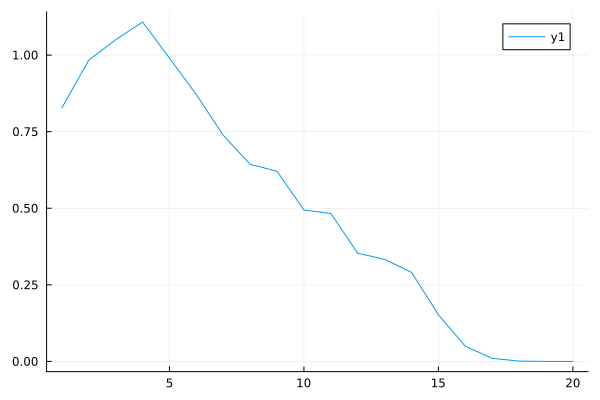

In [153]:
plot(d5a[:,28])

In [158]:
for j in 1:size(d5a,2)
    println(j)
    println(fwd(d5a[:,j]))
end

1
0.5101258005093356
2
0.5420773031489148
3
0.6010998882335343
4
0.6979146340609272
5
0.8530055821424742
6
1.1954205126416628
7
1.605798327539544
8
1.8989098133656537
9
2.131656470461122
10
2.3515525339447567
11
2.5811265008788773
12
2.851215667101444
13
3.2489675939334113
14
3.6195163203327247
15
3.9231400946859134
16
4.18512380455092
17
4.4269760356909185
18
4.671670965631928
19
4.9821335974283265
20
5.391253193994483
21
5.726244940901328
22
6.010751365964642
23
6.260345599622013
24
6.494015732819071
25
6.762913742224241
26
7.102017691944717
27
7.5109929488365506
28
7.800232214240748
29
8.021176339285134
30
8.193044431446285
31
8.333062245792938
32
8.47127576418513
33
8.666443999381439
34
8.768609732888322
35
8.820092130045511
36
8.830253081224068
37
8.815459153592656
38
8.802708920500756
39
8.874660390767673
40
8.871477492865505


In [159]:
[(println(j);fwd(d)) for (j,d) in enumerate(eachcol(d5a))]

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40


40-element Vector{Float64}:
 0.5101258005093356
 0.5420773031489148
 0.6010998882335343
 0.6979146340609272
 0.8530055821424742
 1.1954205126416628
 1.605798327539544
 1.8989098133656537
 2.131656470461122
 2.3515525339447567
 2.5811265008788773
 2.851215667101444
 3.2489675939334113
 ⋮
 8.021176339285134
 8.193044431446285
 8.333062245792938
 8.47127576418513
 8.666443999381439
 8.768609732888322
 8.820092130045511
 8.830253081224068
 8.815459153592656
 8.802708920500756
 8.874660390767673
 8.871477492865505

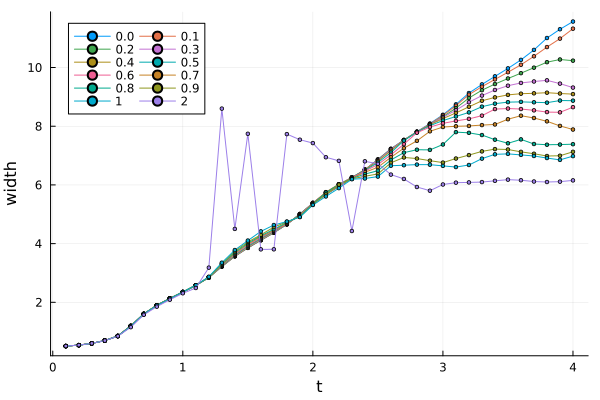

In [167]:
p=plot(;xlabel="t",ylabel="width",legend_columns = 2)
for dU in 0:9
    U=0.1*dU
    filename="data/sprodshort0$dU.hdf5"
    times=h5read(filename,"times")
    sites=h5read(filename,"sites")
    densities=h5read(filename,"densities")
    widths=[fwd(d) for d in eachcol(densities)]
    plot!(times,widths,label="$(round(U,digits=1))",
    marker =:circle,markersize=2)
end
 for U in 1:2
     filename="data/prodshort$U.hdf5"
     times=h5read(filename,"times")
     sites=h5read(filename,"sites")
     densities=h5read(filename,"densities")
     widths=[fwd(d) for d in eachcol(densities)]
     plot!(times,widths,label="$U",marker=:circle,markersize=2)
 end
p
savefig("widths2.png")
p